# Potato Leaf Disease Detection 

## Cell 1 — Import Required Libraries

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers

2026-04-27 08:37:15.143991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777279035.526042      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777279035.627326      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777279036.534441      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777279036.534482      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777279036.534485      55 computation_placer.cc:177] computation placer alr

## Cell 2 — Set Constants

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20

## Cell 3 — Dataset Path



In [4]:
DATASET_PATH = "/kaggle/input/datasets/rizwan123456789/potato-disease-leaf-datasetpld/PLD_3_Classes_256"

print("Dataset folders:", os.listdir(DATASET_PATH))

Dataset folders: ['Validation', 'Training', 'Testing']


## Cell 4 — Load Training, Validation, and Testing Dataset

Because the dataset is already split, we do **not** use `train_test_split` or manual splitting.

In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 3251 files belonging to 3 classes.


I0000 00:00:1777279136.760140      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777279136.766075      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.


## Cell 5 — Check Class Names

In [6]:
class_names = train_ds.class_names
n_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", n_classes)

Class names: ['Early_Blight', 'Healthy', 'Late_Blight']
Number of classes: 3


## Cell 6 — Check One Batch Shape

In [7]:
for image_batch, label_batch in train_ds.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Sample labels:", label_batch[:10].numpy())

Image batch shape: (32, 256, 256, 3)
Label batch shape: (32,)
Sample labels: [0 0 1 1 0 1 0 1 1 2]


## Cell 7 — Visualize Training Images

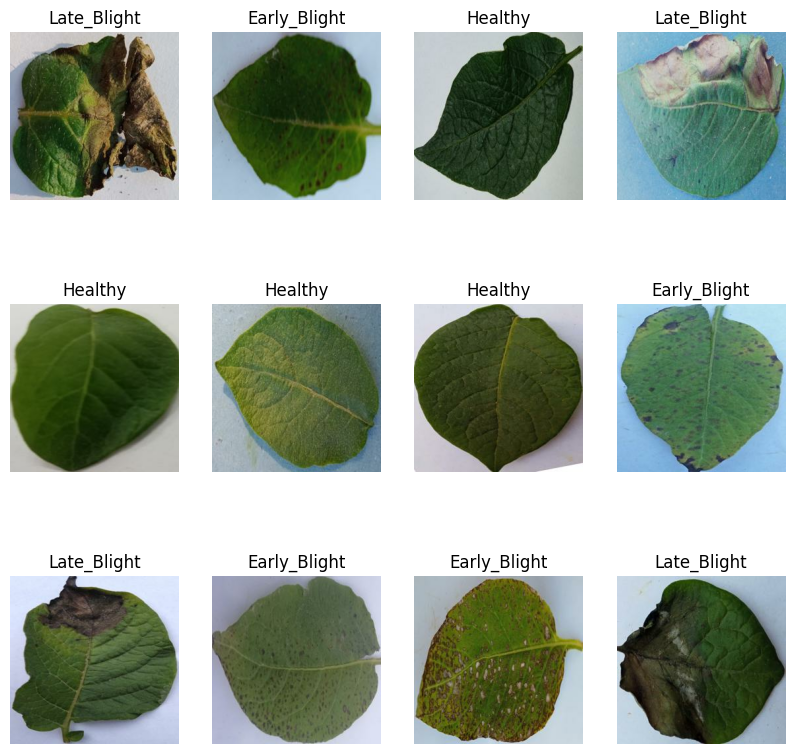

In [8]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in train_ds.take(1):
    for i in range(min(12, len(image_batch))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

plt.show()

## Cell 8 — Check Dataset Batch Counts

In [9]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Training batches: 102
Validation batches: 13
Testing batches: 13


## Cell 9 — Cache, Shuffle, and Prefetch Dataset

Important:
- Shuffle only training dataset.
- Do not shuffle validation/testing.
- Do not apply preprocessing here because preprocessing will be inside the model.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Cell 10 — Create Preprocessing and Data Augmentation Layers

**Preprocessing**
- Resize images to `256 x 256`
- Rescale pixel values from `0–255` to `0–1`

**Data Augmentation**
- Randomly flips images
- Randomly rotates images

These layers are added inside the model, so do not map them separately on dataset.

In [13]:
preprocessing = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
], name="preprocessing")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
], name="data_augmentation")

## Cell 11 — Build CNN Model

Important fix:
- Input shape should be `(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)`
- Do **not** include `BATCH_SIZE` in input shape.

In [14]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
    layers.Input(shape=input_shape),

    preprocessing,
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,341,955 (12.75 MB)

 Trainable params: 3,341,955 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 12 — Compile Model

We use:
- Adam optimizer
- Sparse categorical crossentropy because labels are integer encoded
- Accuracy as evaluation metric

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Cell 13 — Train Model

In [16]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    verbose=1
)

Epoch 1/20


I0000 00:00:1777279718.828433     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.4407 - loss: 1.0986 - val_accuracy: 0.6683 - val_loss: 0.8393
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5554 - loss: 0.9606 - val_accuracy: 0.6154 - val_loss: 0.8201
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7178 - loss: 0.7307 - val_accuracy: 0.7885 - val_loss: 0.5255
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7879 - loss: 0.5575 - val_accuracy: 0.8317 - val_loss: 0.4666
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.7991 - loss: 0.5197 - val_accuracy: 0.6418 - val_loss: 0.7749
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7455 - loss: 0.6427 - val_accuracy: 0.8630 - val_loss: 0.3859
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8417 - loss: 0.4287 - val_accuracy: 0.8822 - val_loss: 0.3553
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8745 - loss: 0.3343 - val_accuracy: 0.88

## Cell 14 — Evaluate Model on Test Dataset

In [17]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.9273 - loss: 0.2103
Test Loss: 0.14714254438877106
Test Accuracy: 0.9506173133850098


## Cell 15 — Check Training History Keys

In [18]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Cell 16 — Plot Accuracy Graph

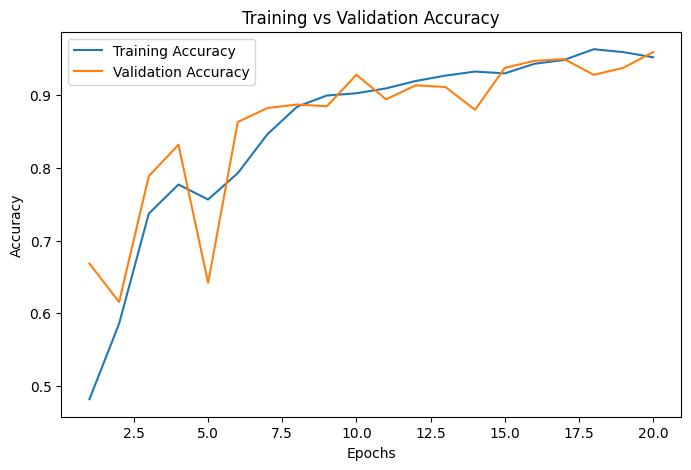

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(acc) + 1), acc, label='Training Accuracy')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Cell 17 — Plot Loss Graph

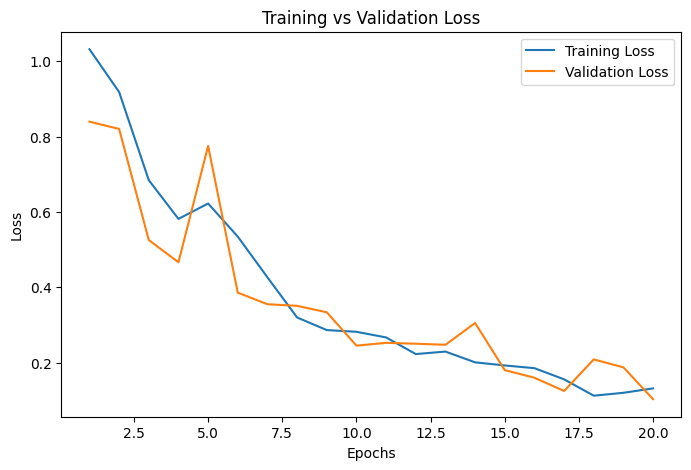

In [20]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss) + 1), loss, label='Training Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Cell 18 — Prediction Function

In [21]:
def predict(model, img):
    """Predict class name and confidence for a single image tensor or numpy image."""

    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

## Cell 19 — Test Prediction on One Image

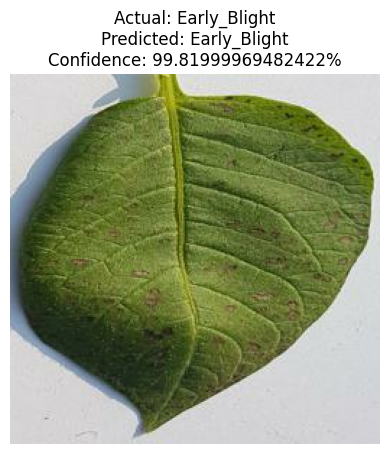

Actual Class: Early_Blight
Predicted Class: Early_Blight
Confidence: 99.82 %


In [22]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()

    predicted_class, confidence = predict(model, first_image)

    plt.imshow(first_image)
    plt.axis("off")
    plt.title(f"Actual: {class_names[first_label]}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
    plt.show()

    print("Actual Class:", class_names[first_label])
    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence, "%")

## Cell 20 — Show Multiple Predictions

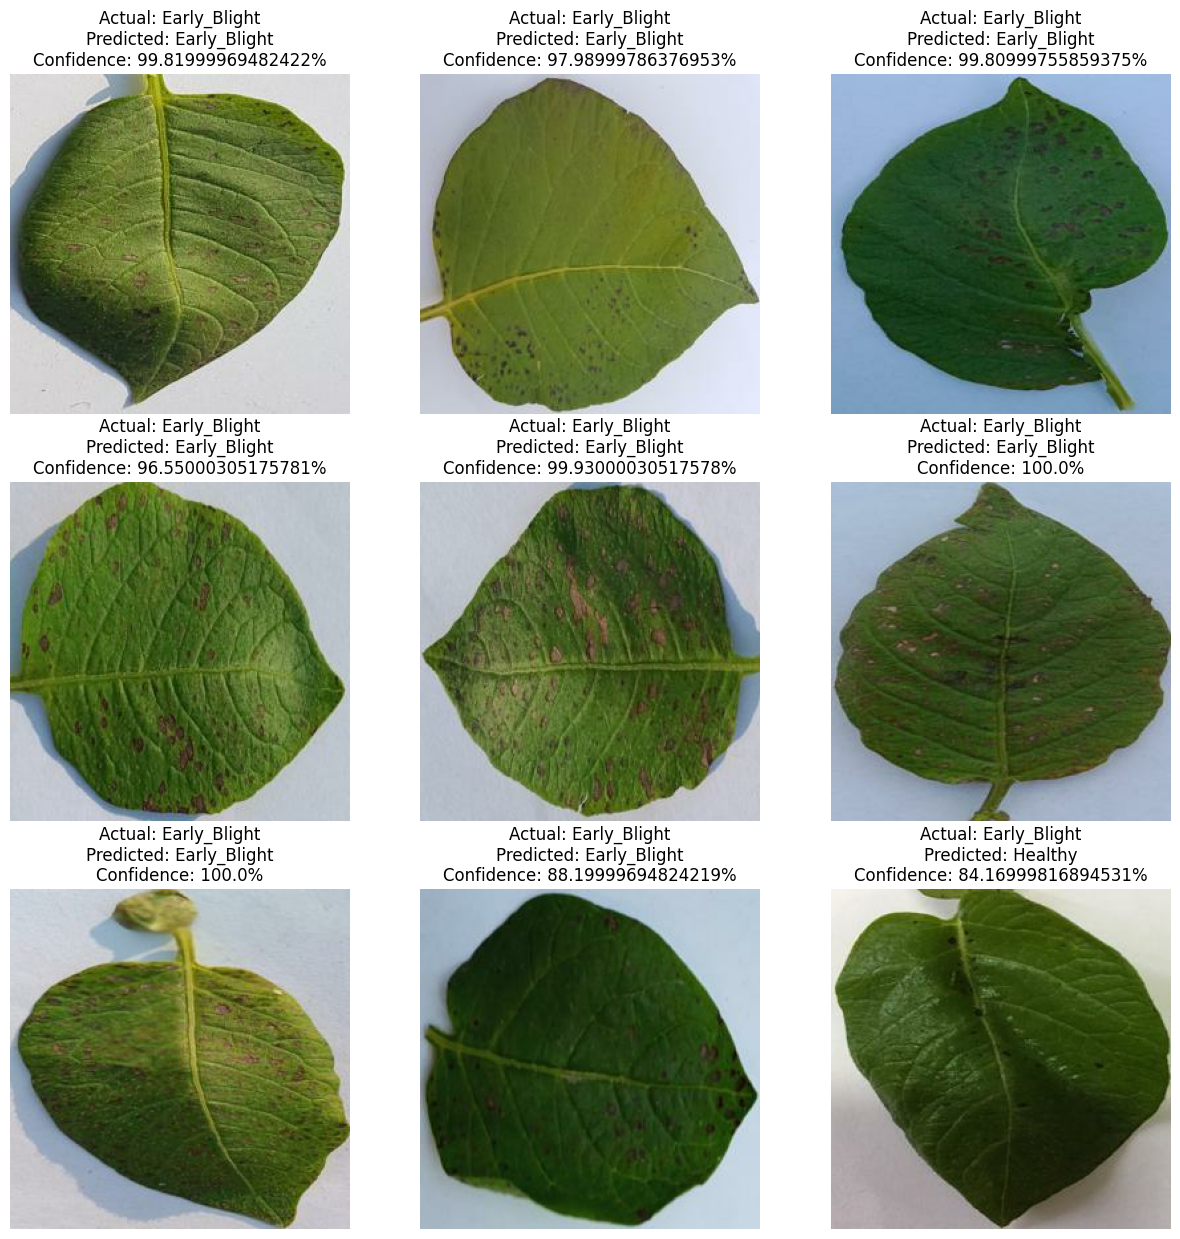

In [23]:
plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        image = images[i].numpy().astype("uint8")
        actual_class = class_names[labels[i]]
        predicted_class, confidence = predict(model, image)

        plt.imshow(image)
        plt.title(
            f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%"
        )
        plt.axis("off")

plt.show()

## Cell 21 — Save Model and Class Names

`.keras` is recommended for newer TensorFlow/Keras versions.

`.h5` is also saved because it is commonly used in Flask web apps.

In [24]:
model.save("potato_disease_model.keras")
model.save("potato_disease_model.h5")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved successfully.")

Model and class names saved successfully.


## Cell 22 — Load Saved Model for Testing

Run this cell only if you want to confirm that the saved model loads correctly.

In [25]:
loaded_model = tf.keras.models.load_model("potato_disease_model.keras")

for images_batch, labels_batch in test_ds.take(1):
    sample_image = images_batch[0].numpy().astype("uint8")
    predicted_class, confidence = predict(loaded_model, sample_image)

    print("Loaded model prediction:", predicted_class)
    print("Confidence:", confidence, "%")
    break

Loaded model prediction: Early_Blight
Confidence: 99.82 %
